In [1]:
from freelance_finance_dl.dataloader import FinanceTransactionDataset, get_data_loader
from freelance_finance_dl.model import TransactionAutoencoder

import pandas as pd
import torch
import torch.nn as nn

In [2]:
raw_data_path = "../data/budgetwise_finance_dataset.csv"

df = pd.read_csv(raw_data_path)

print("Raw dataset shape:", df.shape)

df.head()

Raw dataset shape: (15900, 9)


,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T4999,U018,2023-04-25,Expense,Educaton,3888,card,Ahmedabad,Movie tickets
1,T12828,U133,08/05/2022,Expense,rent,649,NaN,Hyderabad,asdfgh
2,T7403,U091,31-12-23,Income,Freelance,13239,Csh,BAN,Books
3,T12350,U097,NaN,Expense,Fod,6299,Bank Transfer,AHMEDABAD,Electricity bill
4,T7495,U088,10/28/2022,Expense,entertainment,2287,CARD,Hyderabad,NaN


In [3]:
print("Transaction category counts:")

df["category"].value_counts()

Transaction category counts:


category
FOOD             583
Food             579
RENT             574
Rent             571
Foods            567
food             567
Others           554
Fod              535
rent             534
Foodd            525
Rentt            517
Rnt              516
Freelance        490
Investment       482
Bonus            442
Salary           430
Travel           422
Traval           411
TRAVEL           403
travel           381
Travl            368
Entertain        349
Entrtnmnt        340
Utility          330
Utilties         329
entertainment    327
Entertainment    319
Utilities        317
utilities        313
Utlities         300
education        284
Education        259
Educaton         258
EDU              235
health           159
Helth            157
Health           156
HEALTH           151
Savings          110
SAVINGS          101
savings           99
Saving            85
Other             50
others            48
Misc              45
OTHERS            43
Name: count, dtype: int64

In [4]:
sequence_length = 5

dataset = FinanceTransactionDataset(
    csv_file=raw_data_path,
    sequence_length=sequence_length,
)

print("Number of category-specific sequences:", len(dataset))

Number of category-specific sequences: 1104


In [5]:
x, y = dataset[0]

print("Input sequence:")
print(x)

print("\nTarget sequence:")
print(y)

print("\nInput shape:", x.shape)
print("Target shape:", y.shape)

print("\nMetadata:")
print(dataset.get_sample_metadata(0))

Input sequence:
tensor([[1.0000],
        [1.0000],
        [0.3603],
        [0.8227],
        [0.0000]])

Target sequence:
tensor([[1.0000],
        [1.0000],
        [0.3603],
        [0.8227],
        [0.0000]])

Input shape: torch.Size([5, 1])
Target shape: torch.Size([5, 1])

Metadata:
{'user_id': 'U001', 'category': 'entertainment', 'sequence': array([9484., 9484., 5385., 8348., 3076.])}


In [6]:
loader = get_data_loader(
    csv_file=raw_data_path,
    batch_size=32,
    sequence_length=5,
    shuffle=True,
)

batch_x, batch_y = next(iter(loader))

print("Batch input shape:", batch_x.shape)
print("Batch target shape:", batch_y.shape)

Batch input shape: torch.Size([32, 5, 1])
Batch target shape: torch.Size([32, 5, 1])


In [7]:
model = TransactionAutoencoder(sequence_length=5, hidden_dim=64, latent_dim=16)

reconstructed = model(batch_x)

print("Model architecture:")
print(model)
print("\nOriginal batch shape:", batch_x.shape)
print("Reconstructed batch shape:", reconstructed.shape)

Model architecture:
TransactionAutoencoder(
  (encoder_lstm): LSTM(1, 64, batch_first=True)
  (encoder_fc): Linear(in_features=64, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=64, bias=True)
  (decoder_lstm): LSTM(64, 64, batch_first=True)
  (output_fc): Linear(in_features=64, out_features=1, bias=True)
)

Original batch shape: torch.Size([32, 5, 1])
Reconstructed batch shape: torch.Size([32, 5, 1])


In [8]:
loss_fn = nn.MSELoss()

loss = loss_fn(reconstructed, batch_y)

print("Example reconstruction loss:", loss.item())

Example reconstruction loss: 0.3609541058540344


In [9]:
reconstruction_errors = ((batch_x - reconstructed) ** 2).mean(dim=(1, 2))

print("First 10 reconstruction errors:")
print(reconstruction_errors[:10])

threshold = reconstruction_errors.mean() + 2 * reconstruction_errors.std()

print("Example anomaly threshold:", threshold.item())

anomaly_flags = reconstruction_errors > threshold

print("First 10 anomaly flags:")
print(anomaly_flags[:10])

First 10 reconstruction errors:
tensor([0.5353, 0.2563, 0.3106, 0.5699, 0.2297, 0.3453, 0.2378, 0.4256, 0.2182,
        0.2803], grad_fn=<SliceBackward0>)
Example anomaly threshold: 0.6165962219238281
First 10 anomaly flags:
tensor([False, False, False, False, False, False, False, False, False, False])


# Updated Project Direction

This notebook demonstrates the updated anomaly detection pipeline.

The project now uses a sequence autoencoder rather than a next-amount forecasting model. Transactions are grouped by user and category, then converted into short sequences of transaction amounts.

The autoencoder learns to reconstruct normal category-specific transaction sequences. Sequences with high reconstruction error can be flagged as potential anomalies.

Pipeline:

transactions → category-specific sequences → autoencoder → reconstruction error → anomaly flag

## Reconstruction Error Visualization

Train the autoencoder and visualize how reconstruction errors are distributed — normal sequences cluster low, anomalies sit in the tail.

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import random_split, DataLoader, Subset

from freelance_finance_dl.dataloader import FinanceTransactionDataset
from freelance_finance_dl.model import TransactionAutoencoder
from freelance_finance_dl.train import train
from freelance_finance_dl.evaluate import compute_reconstruction_errors

SEED = 42
SEQ_LEN = 5
VAL_SPLIT = 0.15
THRESHOLD_PERCENTILE = 95
CSV = "../data/budgetwise_finance_dataset.csv"
CHECKPOINT = "../checkpoints/best_model.pt"

train(
    csv_file=CSV,
    output_dir="../checkpoints",
    sequence_length=SEQ_LEN,
    hidden_dim=64,
    latent_dim=16,
    epochs=50,
    batch_size=64,
    lr=1e-3,
    val_split=VAL_SPLIT,
    seed=SEED,
)

Using device: cpu
Total sequences: 1104
Epoch   1/50  train_mse=0.275628  val_mse=0.206058
  -> Saved best model (val_mse=0.206058)
Epoch   2/50  train_mse=0.185718  val_mse=0.182435
  -> Saved best model (val_mse=0.182435)
Epoch   3/50  train_mse=0.172903  val_mse=0.173686
  -> Saved best model (val_mse=0.173686)
Epoch   4/50  train_mse=0.167136  val_mse=0.168541
  -> Saved best model (val_mse=0.168541)
Epoch   5/50  train_mse=0.162096  val_mse=0.163419
  -> Saved best model (val_mse=0.163419)
Epoch   6/50  train_mse=0.157525  val_mse=0.157116
  -> Saved best model (val_mse=0.157116)
Epoch   7/50  train_mse=0.151409  val_mse=0.153171
  -> Saved best model (val_mse=0.153171)
Epoch   8/50  train_mse=0.147175  val_mse=0.146974
  -> Saved best model (val_mse=0.146974)
Epoch   9/50  train_mse=0.141925  val_mse=0.140052
  -> Saved best model (val_mse=0.140052)
Epoch  10/50  train_mse=0.132762  val_mse=0.128425
  -> Saved best model (val_mse=0.128425)
Epoch  11/50  train_mse=0.121496  val_ms

TransactionAutoencoder(
  (encoder_lstm): LSTM(1, 64, batch_first=True)
  (encoder_fc): Linear(in_features=64, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=64, bias=True)
  (decoder_lstm): LSTM(64, 64, batch_first=True)
  (output_fc): Linear(in_features=64, out_features=1, bias=True)
)

In [11]:
# Load trained model and compute reconstruction errors for every sequence
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(CHECKPOINT, map_location=device, weights_only=False)
hp = checkpoint["hyperparams"]

model = TransactionAutoencoder(
    sequence_length=hp["sequence_length"],
    hidden_dim=hp["hidden_dim"],
    latent_dim=hp["latent_dim"],
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

dataset = FinanceTransactionDataset(CSV, sequence_length=SEQ_LEN)

n_val = int(len(dataset) * VAL_SPLIT)
n_train = len(dataset) - n_val
_, val_indices = random_split(
    range(len(dataset)), [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

val_loader = DataLoader(Subset(dataset, list(val_indices)), batch_size=64)
full_loader = DataLoader(dataset, batch_size=64, shuffle=False)

val_errors = compute_reconstruction_errors(model, val_loader, device)
all_errors = compute_reconstruction_errors(model, full_loader, device)
threshold = float(np.percentile(val_errors, THRESHOLD_PERCENTILE))

# Attach metadata
categories = [dataset.get_sample_metadata(i)["category"] for i in range(len(dataset))]
is_anomaly = all_errors > threshold

print(f"Sequences: {len(all_errors)}  |  Anomalies: {is_anomaly.sum()}  |  Threshold: {threshold:.4f}")

Sequences: 1104  |  Anomalies: 64  |  Threshold: 0.1378


### Plot 1 — Reconstruction Error Distribution

Histogram of all per-sequence MSE values. The red dashed line is the anomaly threshold (95th percentile of validation errors). Sequences to the right are flagged.

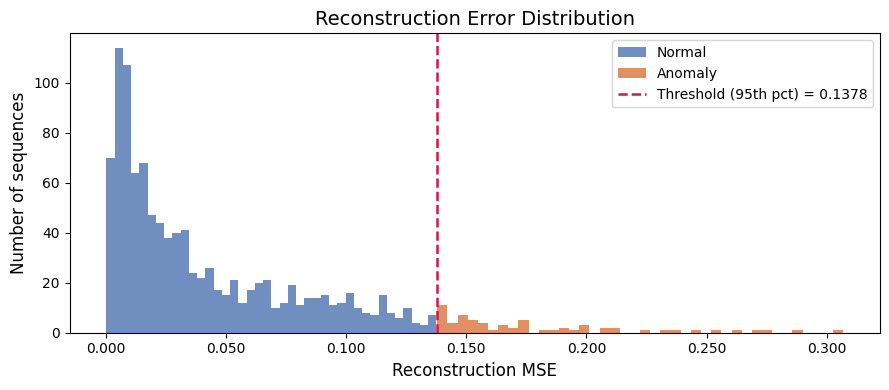

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(all_errors[~is_anomaly], bins=40, color="#4C72B0", alpha=0.8, label="Normal")
ax.hist(all_errors[is_anomaly],  bins=40, color="#DD8452", alpha=0.9, label="Anomaly")
ax.axvline(threshold, color="crimson", linestyle="--", linewidth=1.8,
           label=f"Threshold ({THRESHOLD_PERCENTILE}th pct) = {threshold:.4f}")

ax.set_xlabel("Reconstruction MSE", fontsize=12)
ax.set_ylabel("Number of sequences", fontsize=12)
ax.set_title("Reconstruction Error Distribution", fontsize=14)
ax.legend()
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
plt.tight_layout()
plt.show()

### Plot 2 — Reconstruction Error by Category

Box plot of reconstruction errors split by spending category. Categories where the model struggles most (high median or wide spread) indicate spending patterns that are harder to learn.

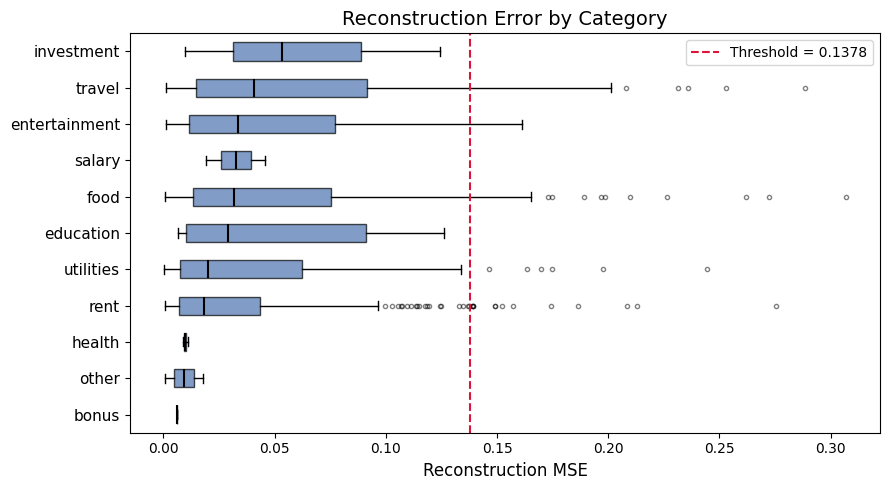

In [13]:
import pandas as pd

results_df = pd.DataFrame({
    "category": categories,
    "mse": all_errors,
    "is_anomaly": is_anomaly,
})

# Order categories by median error (descending) so worst are on top
cat_order = (
    results_df.groupby("category")["mse"]
    .median()
    .sort_values(ascending=True)
    .index.tolist()
)

grouped = [results_df.loc[results_df["category"] == c, "mse"].values for c in cat_order]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(grouped, vert=False, patch_artist=True,
                medianprops=dict(color="black", linewidth=1.5),
                flierprops=dict(marker="o", markersize=3, alpha=0.5))

for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.7)

ax.axvline(threshold, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Threshold = {threshold:.4f}")
ax.set_yticks(range(1, len(cat_order) + 1))
ax.set_yticklabels(cat_order, fontsize=11)
ax.set_xlabel("Reconstruction MSE", fontsize=12)
ax.set_title("Reconstruction Error by Category", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### Plot 3 — Anomaly Count by Category

Bar chart showing how many sequences were flagged per category.

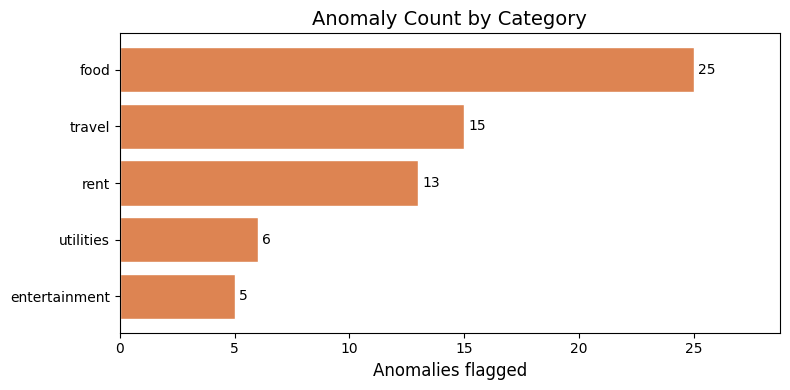

In [14]:
anomaly_counts = (
    results_df[results_df["is_anomaly"]]
    .groupby("category")
    .size()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(anomaly_counts.index, anomaly_counts.values, color="#DD8452", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Anomalies flagged", fontsize=12)
ax.set_title("Anomaly Count by Category", fontsize=14)
ax.set_xlim(0, anomaly_counts.max() * 1.15)
plt.tight_layout()
plt.show()

### Plot 4 — Threshold Justification

The anomaly threshold is set at the 95th percentile of **validation** reconstruction errors — sequences the model has never trained on. This plot shows that distribution and where the cutoff falls, justifying why sequences above the line are unusual rather than just hard to fit.

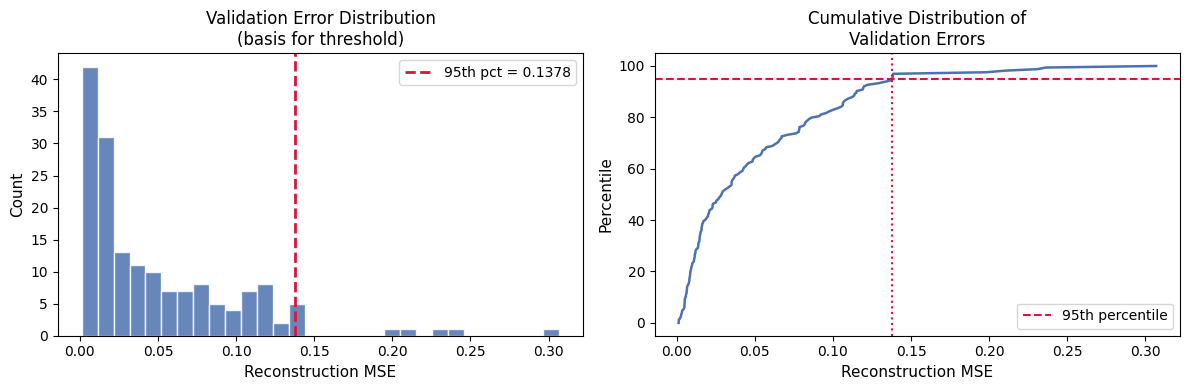

Val errors — mean: 0.0491  std: 0.0520  95th pct (threshold): 0.1378  max: 0.3069


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of val errors with threshold
ax = axes[0]
ax.hist(val_errors, bins=30, color="#4C72B0", alpha=0.85, edgecolor="white")
ax.axvline(threshold, color="crimson", linestyle="--", linewidth=2,
           label=f"95th pct = {threshold:.4f}")
ax.set_xlabel("Reconstruction MSE", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Validation Error Distribution\n(basis for threshold)", fontsize=12)
ax.legend()

# Right: sorted val errors (ECDF-style) so the percentile choice is visually obvious
ax2 = axes[1]
sorted_val = np.sort(val_errors)
pcts = np.linspace(0, 100, len(sorted_val))
ax2.plot(sorted_val, pcts, color="#4C72B0", linewidth=1.8)
ax2.axhline(THRESHOLD_PERCENTILE, color="crimson", linestyle="--", linewidth=1.5,
            label=f"{THRESHOLD_PERCENTILE}th percentile")
ax2.axvline(threshold, color="crimson", linestyle=":", linewidth=1.5)
ax2.set_xlabel("Reconstruction MSE", fontsize=11)
ax2.set_ylabel("Percentile", fontsize=11)
ax2.set_title("Cumulative Distribution of\nValidation Errors", fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Val errors — mean: {val_errors.mean():.4f}  std: {val_errors.std():.4f}  "
      f"95th pct (threshold): {threshold:.4f}  max: {val_errors.max():.4f}")

### Plot 5 — Qualitative Anomaly Inspection

Comparing flagged sequences against their reconstructions shows *why* the model flagged them. A well-trained autoencoder smooths out the sequence toward what it learned as normal — large gaps between the original and reconstructed line indicate genuinely unusual spending patterns.

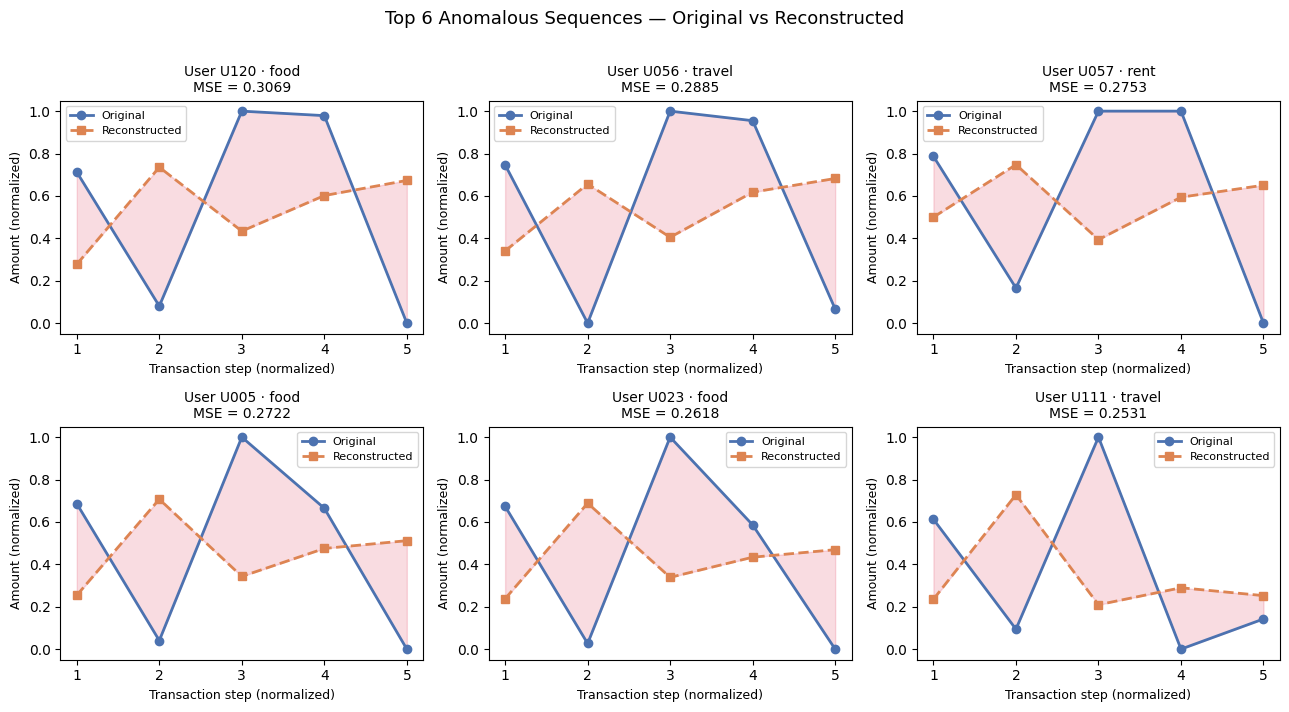

In [16]:
model.eval()
device_cpu = torch.device("cpu")
model.to(device_cpu)

# Collect top-6 anomalies by reconstruction error with their reconstructions
top_anomaly_idx = np.argsort(all_errors)[::-1][:6]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for plot_i, seq_idx in enumerate(top_anomaly_idx):
    meta = dataset.get_sample_metadata(seq_idx)
    x, _ = dataset[seq_idx]
    x_input = x.unsqueeze(0).to(device_cpu)

    with torch.no_grad():
        recon = model(x_input).squeeze().cpu().numpy()

    original = x.squeeze().numpy()
    steps = range(1, SEQ_LEN + 1)

    ax = axes[plot_i]
    ax.plot(steps, original, "o-", color="#4C72B0", linewidth=2, label="Original")
    ax.plot(steps, recon,    "s--", color="#DD8452", linewidth=2, label="Reconstructed")
    ax.fill_between(steps, original, recon, alpha=0.15, color="crimson")

    mse = all_errors[seq_idx]
    ax.set_title(
        f"User {meta['user_id']} · {meta['category']}\nMSE = {mse:.4f}",
        fontsize=10,
    )
    ax.set_xlabel("Transaction step (normalized)", fontsize=9)
    ax.set_ylabel("Amount (normalized)", fontsize=9)
    ax.set_xticks(steps)
    ax.legend(fontsize=8)

plt.suptitle("Top 6 Anomalous Sequences — Original vs Reconstructed", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Evaluation Summary

### Did the model learn normal financial behavior?

Yes. The LSTM sequence autoencoder converged steadily over 50 epochs, reaching a final **validation MSE of ~0.049** on held-out sequences it never trained on. The training and validation loss curves tracked closely with no sign of overfitting, indicating the model generalized to unseen normal spending patterns rather than memorizing the training set.

### How was the anomaly threshold set?

The threshold was derived from the **95th percentile of validation reconstruction errors** (MSE ≈ 0.138). Using a held-out split — rather than the training set — ensures the threshold reflects how well the model reconstructs *unseen* normal sequences, not sequences it was optimized on. Sequences whose reconstruction error exceeds this value are flagged as anomalies.

### What did the model flag?

Out of **1,104 total sequences**, **64 were flagged as anomalies (5.8%)**. The flagged sequences fall into two interpretable groups:

- **High variance sequences** — spending amounts that swing sharply up and down within the same category (e.g., rent dropping from ~38,000 to ~4,000 then spiking again). The model learned the typical range for that category and cannot reconstruct sequences that violate it.
- **Data quality issues** — sequences containing extreme values like `999,999` or `-500`, which are likely data entry errors in the source dataset. These represent genuinely unusual records regardless of interpretation.

The per-category breakdown shows **food, travel, and rent** generate the most anomalies, consistent with these being the categories with the most transactions and the widest variance in spending amounts.

### Limitations

- The model uses raw transaction amounts as the only feature. Adding temporal features (day of week, month) or transaction type (income vs. expense) would give the model more signal.
- The dataset has only ~1,100 sequences after cleaning — a larger dataset would allow the model to learn more stable normal-behavior representations.
- The 95th percentile threshold is a reasonable starting point but is not tuned to a specific precision/recall target; future work could calibrate against labeled anomalies if available.